In [1]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()

df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [10]:
df_in=df[(df['job_country']=='India')].dropna(subset='salary_year_avg')
job_titles=df_in['job_title_short'].value_counts().index[:6].tolist()
job_titles

['Data Engineer',
 'Data Analyst',
 'Data Scientist',
 'Machine Learning Engineer',
 'Senior Data Engineer',
 'Software Engineer']

In [15]:
df_in_top6=df_in[df_in['job_title_short'].isin(job_titles)]


In [23]:
job_order=df_in_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

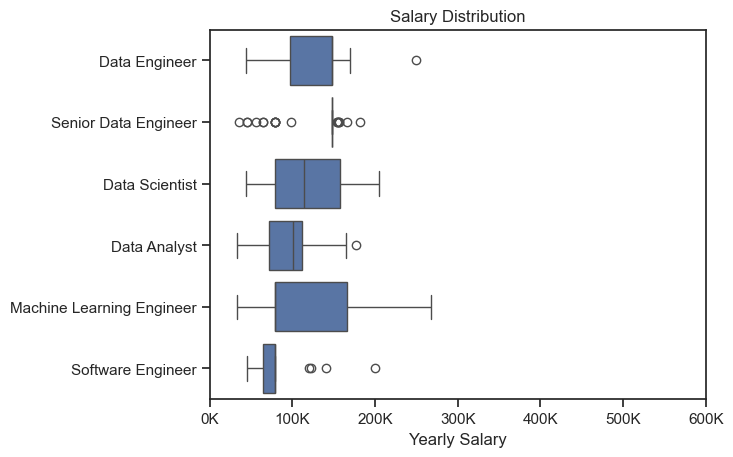

In [24]:
sns.boxplot(data=df_in_top6, x='salary_year_avg',y='job_title_short', order=job_order)
sns.set_theme(style='ticks')

plt.title('Salary Distribution')
plt.ylabel('')
plt.xlabel('Yearly Salary')
ticks_x=plt.FuncFormatter(lambda y,pos:f'{int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.xlim(0,600000)
plt.show()